# THE UNIVERSITY OF LAHORE
**Faculty of Information Technology | Department of Computer Science & IT**

**CS-13410 — Introduction to Machine Learning | Fall 2026 | BSCS**

## Semester Project — Part 1: Data Preparation & Leakage-Free Pipeline
*Submitted with Assignment 1 · Week 5 · Due 08-10-2026 · CLO-2*

| Group Member | Student ID |
| --- | --- |
| Faiza Saleem Mian | 70149372 |
| Khadija Shakeel | 70149379 |
| Manahil Shahzad | 70150284 |

**Project title:** Predicting Stroke Risk from Patient Health Records

## 1. Problem Framing & Dataset Justification

**Clinical question.** Stroke is one of the leading causes of death and disability worldwide. Can routine patient information (age, blood pressure history, heart disease, glucose level, BMI, lifestyle) be used to flag the patients at the highest risk of stroke, so that screening and preventive care can be directed to them first?

| Item | Decision |
| --- | --- |
| **Dataset** | *Stroke Prediction Dataset* by fedesoriano, published on Kaggle (`https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset`). One row = one patient. |
| **Prediction target** | `stroke` — 1 if the patient had a stroke, 0 if not |
| **Task type** | Supervised **binary classification** |
| **Positive class** | Stroke (`stroke = 1`), because missing an at-risk patient is the costly mistake |
| **Success metrics** | **ROC-AUC**, **PR-AUC (average precision)**, and **recall / F1 of the stroke class**. Plain accuracy is *not* used: only about 5% of patients had a stroke, so a model that predicts "no stroke" for everyone would already score about 95%. |
| **Evaluation rule** | Stratified train/test split made **before** any preprocessing is fitted; the test set stays untouched until final evaluation. |

**Why this dataset is suitable**

- **Size:** 5,110 patient records, well above the 1,000-row minimum.
- **Mixed features:** continuous (`age`, `avg_glucose_level`, `bmi`), binary (`hypertension`, `heart_disease`, `ever_married`, `Residence_type`) and nominal categorical (`gender`, `work_type`, `smoking_status`) variables, so every preprocessing step in the brief is genuinely needed.
- **Real preprocessing challenges:** missing BMI values, outliers in glucose and BMI, an identifier column, an "Unknown" smoking category, and **severe class imbalance** (about 4.9% positive).
- **Room for later parts:** supports tree models and ensembles (Parts 2–3), a neural network and clustering/PCA of patient profiles (Part 4), and a natural interpretability and fairness discussion in a medical setting (Part 4).
- **Privacy and licensing:** patients are identified only by an anonymous number. The dataset is distributed on Kaggle for **educational use** and asks users to credit the author (fedesoriano), which we do here. This project is for learning only and the model must never be used for real clinical decisions.

## 2. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
print("Libraries loaded.")

Libraries loaded.


## 3. Load the Data

This notebook runs in **Google Colab** (and also in Jupyter). All libraries used are already installed in Colab, so there is nothing to install.

The cell below looks for `healthcare-dataset-stroke-data.csv` next to the notebook. In a fresh Colab session the file is not there, so the notebook automatically downloads a public copy of the Kaggle file. To use your own download from Kaggle instead, set `USE_UPLOAD = True` and choose the file when Colab asks.

In [2]:
import os, sys

IN_COLAB = "google.colab" in sys.modules
LOCAL_FILE = "healthcare-dataset-stroke-data.csv"
MIRROR_URL = "https://raw.githubusercontent.com/arudaev/Project-Arepo/main/data/raw/healthcare-dataset-stroke-data.csv"
USE_UPLOAD = False   # set True in Colab to upload your own copy of the Kaggle CSV

if USE_UPLOAD and IN_COLAB and not os.path.exists(LOCAL_FILE):
    from google.colab import files
    files.upload()   # choose healthcare-dataset-stroke-data.csv

source = LOCAL_FILE if os.path.exists(LOCAL_FILE) else MIRROR_URL
df_raw = pd.read_csv(source)

print("Running in Colab:", IN_COLAB)
print("Data loaded from:", "local file" if source == LOCAL_FILE else "public copy (automatic download)")
print("Shape:", df_raw.shape)
df_raw.head()

Running in Colab: False
Data loaded from: local file
Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Data dictionary

| Column | Type | Meaning |
| --- | --- | --- |
| `id` | identifier | Anonymous patient number (**dropped**, carries no medical information) |
| `gender` | nominal | Male, Female or Other |
| `age` | continuous | Age in years (infants have fractional ages) |
| `hypertension` | binary | 1 if the patient has hypertension |
| `heart_disease` | binary | 1 if the patient has a heart disease |
| `ever_married` | binary (Yes/No) | Whether the patient has ever been married |
| `work_type` | nominal | children, Govt_job, Never_worked, Private, Self-employed |
| `Residence_type` | binary (Rural/Urban) | Type of residence |
| `avg_glucose_level` | continuous | Average blood glucose level (mg/dL) |
| `bmi` | continuous | Body mass index |
| `smoking_status` | nominal | formerly smoked, never smoked, smokes, Unknown (information not available) |
| **`stroke`** | **binary target** | **1 = had a stroke, 0 = no stroke** |

## 4. Data Quality Audit

Before any modelling we check data types, missing values, duplicates, identifiers and value ranges.

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [4]:
missing = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_percent": (df_raw.isna().mean() * 100).round(1),
})
print(missing[missing.missing_count > 0])
print("\nTotal missing cells:", int(df_raw.isna().sum().sum()))
print("Duplicate rows:", int(df_raw.duplicated().sum()))
print("Duplicate patient ids:", int(df_raw["id"].duplicated().sum()))
print("\nsmoking_status value counts:")
print(df_raw["smoking_status"].value_counts())
print("\ngender value counts:")
print(df_raw["gender"].value_counts())
df_raw.describe().T.round(2)

     missing_count  missing_percent
bmi            201              3.9

Total missing cells: 201
Duplicate rows: 0
Duplicate patient ids: 0

smoking_status value counts:
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

gender value counts:
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.83,21161.72,67.00,17741.25,36932.00,54682.00,72940.00
age,5110.0,43.23,22.61,0.08,25.00,45.00,61.00,82.00
hypertension,5110.0,0.10,0.30,0.00,0.00,0.00,0.00,1.00
heart_disease,5110.0,0.05,0.23,0.00,0.00,0.00,0.00,1.00
avg_glucose_level,5110.0,106.15,45.28,55.12,77.24,91.88,114.09,271.74
bmi,4909.0,28.89,7.85,10.30,23.50,28.10,33.10,97.60
stroke,5110.0,0.05,0.22,0.00,0.00,0.00,0.00,1.00


**Findings**

- **Missing values:** only `bmi` has gaps (201 patients, 3.9%). We do **not** delete these rows, because the stroke class has only 249 patients and every row matters. Instead the pipeline imputes BMI with the **median learned from the training set**. Missingness itself looks informative (see Section 5.2), so we also keep a `bmi_missing` indicator.
- **Hidden missing values:** `smoking_status` contains **1,544 "Unknown"** entries (30%). This is not a blank cell but it is effectively missing information. These are mostly younger patients (the dataset description states that Unknown means the information is unavailable), so we keep "Unknown" as its **own category** instead of guessing a value.
- **No duplicates**, and every `id` is unique, so no patient can appear in both train and test. `id` is only an identifier and is excluded from the model.
- **Rare category:** `gender = "Other"` appears only once. One-hot encoding with `handle_unknown="ignore"` keeps the pipeline safe whichever split that row lands in.
- Value ranges look plausible: ages 0.08–82, glucose 55–272 mg/dL, BMI 10.3–97.6 (the highest BMI values are physiologically doubtful and are handled as outliers).

In [5]:
df = df_raw.copy()

# Basic sanity checks on value ranges (NaN is allowed and handled later)
assert df["age"].between(0, 120).all()
assert df["avg_glucose_level"].between(30, 400).all()
assert df["bmi"].dropna().between(5, 100).all()
assert set(df["stroke"].unique()) == {0, 1}
assert df["id"].is_unique
print("Sanity checks passed. Rows:", len(df))

print("\nTarget distribution:")
print(df["stroke"].value_counts().rename({0: "No stroke", 1: "Stroke"}))
print((df["stroke"].value_counts(normalize=True) * 100).round(1).rename({0: "No stroke %", 1: "Stroke %"}))

Sanity checks passed. Rows: 5110

Target distribution:
stroke
No stroke    4861
Stroke        249
Name: count, dtype: int64
stroke
No stroke %    95.1
Stroke %        4.9
Name: proportion, dtype: float64


## 5. Exploratory Data Analysis (EDA)

EDA is done on the full dataset for *understanding only*. No statistic from these plots is used to fit any transformation — all fitting happens later, on the training split.

### 5.1 Class balance of the target

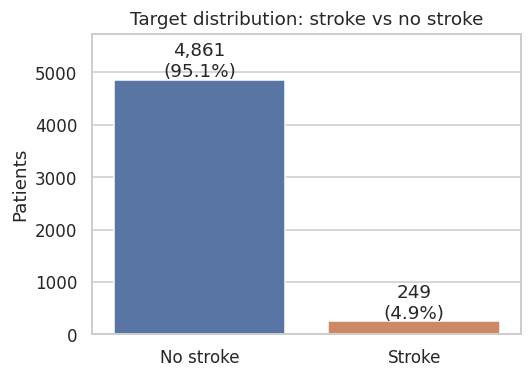

In [6]:
fig, ax = plt.subplots(figsize=(5, 3.6))
counts = df["stroke"].map({0: "No stroke", 1: "Stroke"}).value_counts()
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=["#4c72b0", "#dd8452"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 60, f"{v:,}\n({v/len(df):.1%})", ha="center")
ax.set_title("Target distribution: stroke vs no stroke")
ax.set_ylabel("Patients"); ax.set_xlabel("")
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout(); plt.show()

**Observation:** only 249 of 5,110 patients (4.9%) had a stroke, so the data is **severely imbalanced**. Accuracy would be misleading; we use ROC-AUC, PR-AUC, recall and F1, and handle imbalance in Section 8.

### 5.2 Missing values and what they reveal

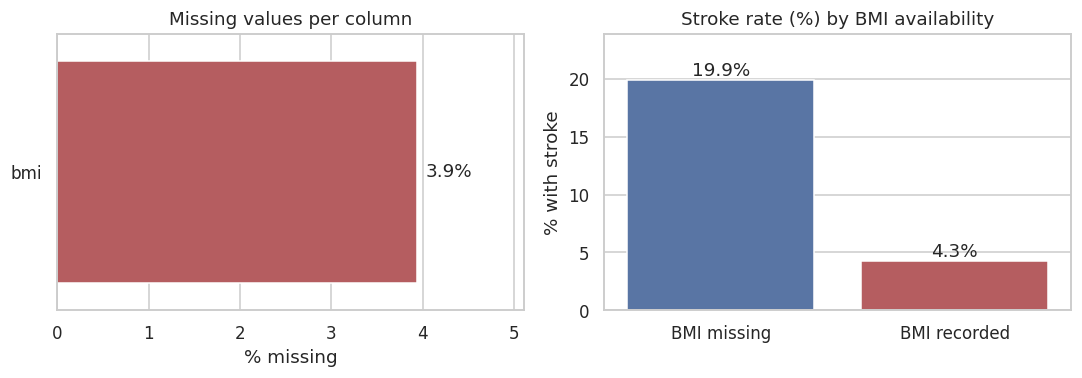

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
miss_pct = (df.isna().mean() * 100)
miss_pct = miss_pct[miss_pct > 0]
sns.barplot(x=miss_pct.values, y=miss_pct.index, ax=axes[0], color="#c44e52")
for i, v in enumerate(miss_pct.values):
    axes[0].text(v + 0.1, i, f"{v:.1f}%", va="center")
axes[0].set_title("Missing values per column")
axes[0].set_xlabel("% missing"); axes[0].set_ylabel("")
axes[0].set_xlim(0, miss_pct.max() * 1.3)

rate_missing = df.groupby(df["bmi"].isna().map({False: "BMI recorded", True: "BMI missing"}))["stroke"].mean() * 100
sns.barplot(x=rate_missing.index, y=rate_missing.values, ax=axes[1], palette=["#4c72b0", "#c44e52"])
for i, v in enumerate(rate_missing.values):
    axes[1].text(i, v + 0.4, f"{v:.1f}%", ha="center")
axes[1].set_title("Stroke rate (%) by BMI availability")
axes[1].set_ylabel("% with stroke"); axes[1].set_xlabel("")
axes[1].set_ylim(0, rate_missing.max() * 1.2)
plt.tight_layout(); plt.show()

**Observation:** only `bmi` is missing (3.9%), but patients with a missing BMI have a much higher stroke rate (about 19.9% vs 4.3%), so the missingness is **not random**. Simply deleting those rows would remove a lot of the stroke patients (40 of the 249), which is another reason to impute and to add a `bmi_missing` indicator. This pattern may be a quirk of how the data was collected, so it should be treated with caution in later parts.

### 5.3 Age and stroke

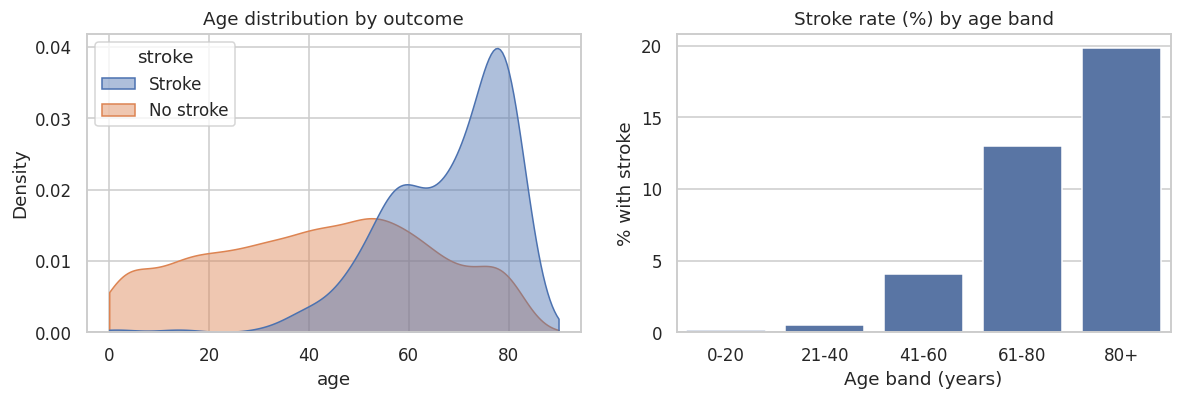

stroke
mean age, no stroke    42.0
mean age, stroke       67.7
Name: age, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.kdeplot(data=df, x="age", hue=df["stroke"].map({0: "No stroke", 1: "Stroke"}),
            fill=True, common_norm=False, alpha=0.45, clip=(0, 90), ax=axes[0])
axes[0].set_title("Age distribution by outcome")

bands = pd.cut(df["age"], [0, 20, 40, 60, 80, 100], labels=["0-20", "21-40", "41-60", "61-80", "80+"])
rate_age = df.groupby(bands, observed=True)["stroke"].mean() * 100
sns.barplot(x=rate_age.index.astype(str), y=rate_age.values, ax=axes[1], color="#4c72b0")
axes[1].set_title("Stroke rate (%) by age band")
axes[1].set_xlabel("Age band (years)"); axes[1].set_ylabel("% with stroke")
plt.tight_layout(); plt.show()

print(df.groupby("stroke")["age"].mean().round(1).rename({0: "mean age, no stroke", 1: "mean age, stroke"}))

**Observation:** age is by far the strongest pattern. Stroke patients are on average about 68 years old versus 42 for the rest, and the stroke rate climbs from almost zero below 40 to about 13% at 61–80 and about 20% above 80.

### 5.4 Glucose level and BMI versus stroke

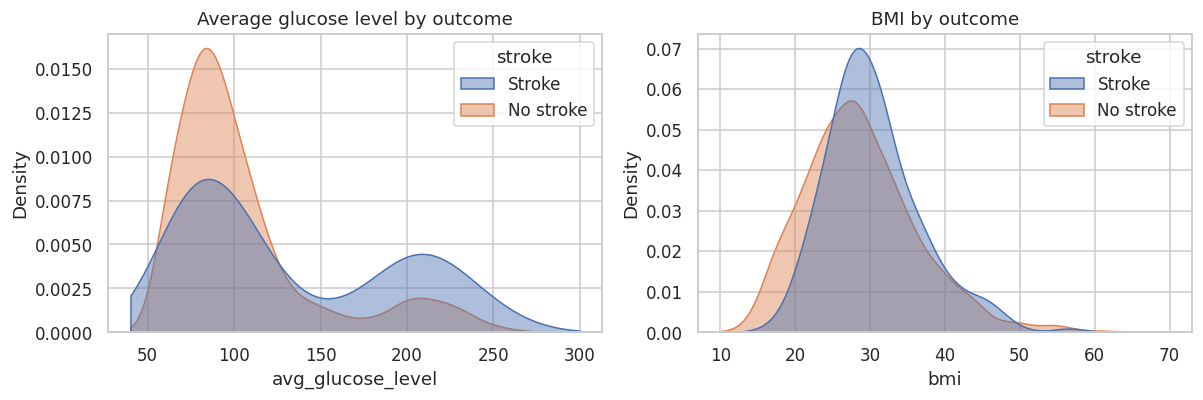

        avg_glucose_level   bmi
stroke                         
0                   104.8  28.8
1                   132.5  30.5


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.kdeplot(data=df, x="avg_glucose_level", hue=df["stroke"].map({0: "No stroke", 1: "Stroke"}),
            fill=True, common_norm=False, alpha=0.45, clip=(40, 300), ax=axes[0])
axes[0].set_title("Average glucose level by outcome")

sns.kdeplot(data=df, x="bmi", hue=df["stroke"].map({0: "No stroke", 1: "Stroke"}),
            fill=True, common_norm=False, alpha=0.45, clip=(10, 70), ax=axes[1])
axes[1].set_title("BMI by outcome")
plt.tight_layout(); plt.show()

print(df.groupby("stroke")[["avg_glucose_level", "bmi"]].mean().round(1))

**Observation:** stroke patients have a higher average glucose level (about 133 vs 105 mg/dL) and the glucose distribution has a second hump at high values (a diabetic range) that is more pronounced for stroke patients. BMI differs only slightly (about 30.5 vs 28.8), so it is a weaker predictor on its own.

### 5.5 Medical history and lifestyle

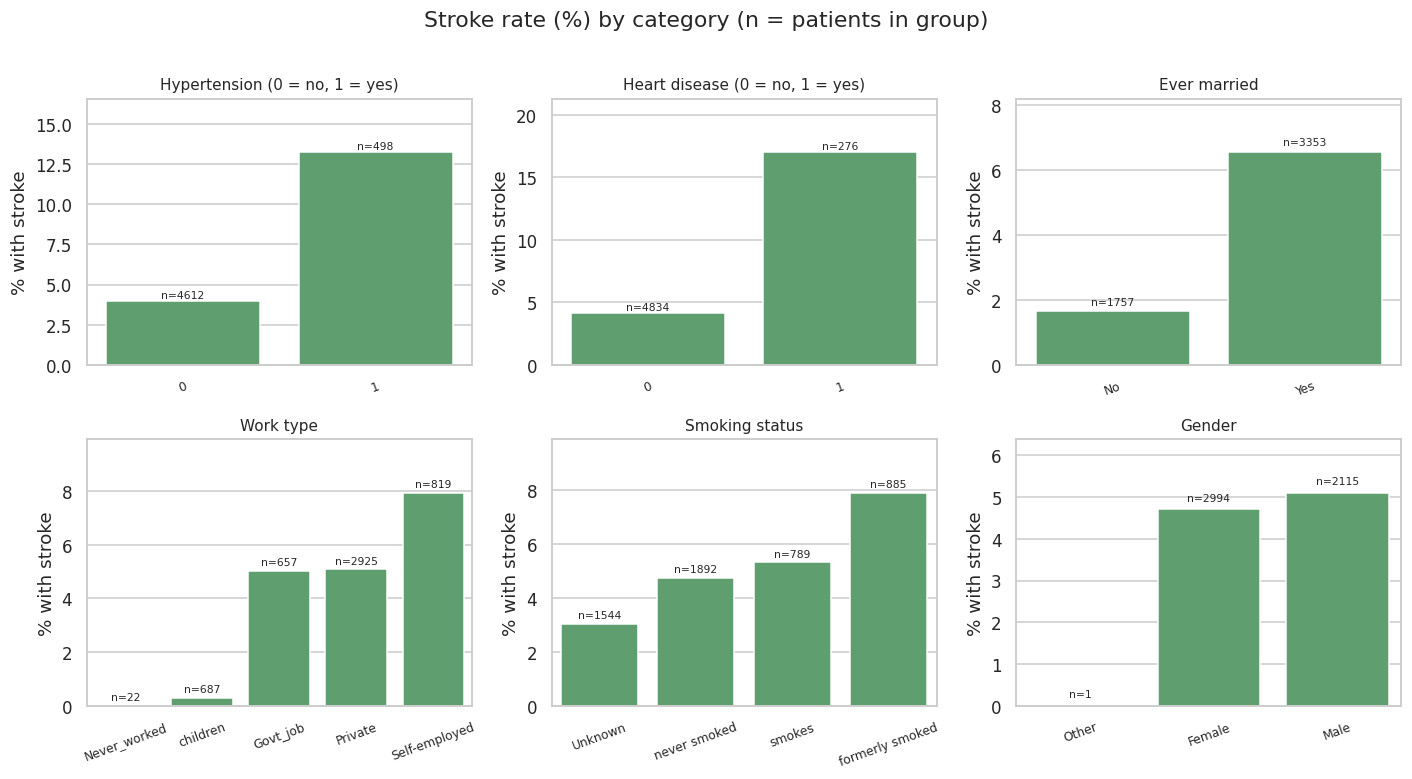

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
cats = [("hypertension", "Hypertension (0 = no, 1 = yes)"), ("heart_disease", "Heart disease (0 = no, 1 = yes)"),
        ("ever_married", "Ever married"), ("work_type", "Work type"),
        ("smoking_status", "Smoking status"), ("gender", "Gender")]
for ax, (col, title) in zip(axes.ravel(), cats):
    stats = df.groupby(col)["stroke"].agg(rate="mean", n="size")
    stats = stats.sort_values("rate")
    sns.barplot(x=stats.index.astype(str), y=stats["rate"] * 100, ax=ax, color="#55a868")
    for i, (r, n) in enumerate(zip(stats["rate"], stats["n"])):
        ax.text(i, r * 100 + 0.2, f"n={n}", ha="center", fontsize=7)
    ax.set_title(title, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("% with stroke")
    ax.tick_params(axis="x", labelsize=8, rotation=20)
    ax.set_ylim(0, max(stats["rate"] * 100) * 1.25)
plt.suptitle("Stroke rate (%) by category (n = patients in group)", y=1.01)
plt.tight_layout(); plt.show()

**Observation:** hypertension (13.3% vs 4.0%) and heart disease (17.0% vs 4.2%) multiply the stroke rate roughly three to four times. Married patients show a higher rate (6.6% vs 1.7%), but this is mostly an **age effect** (older people are more often married) rather than a direct cause. Self-employed patients and former smokers also show higher rates, while the "Unknown" smoking group is lowest because it contains many young patients. Gender looks almost identical (about 4.7% vs 5.1%). Small groups (`Never_worked` n=22, `Other` gender n=1) are too small to trust.

### 5.6 Correlation between numeric features

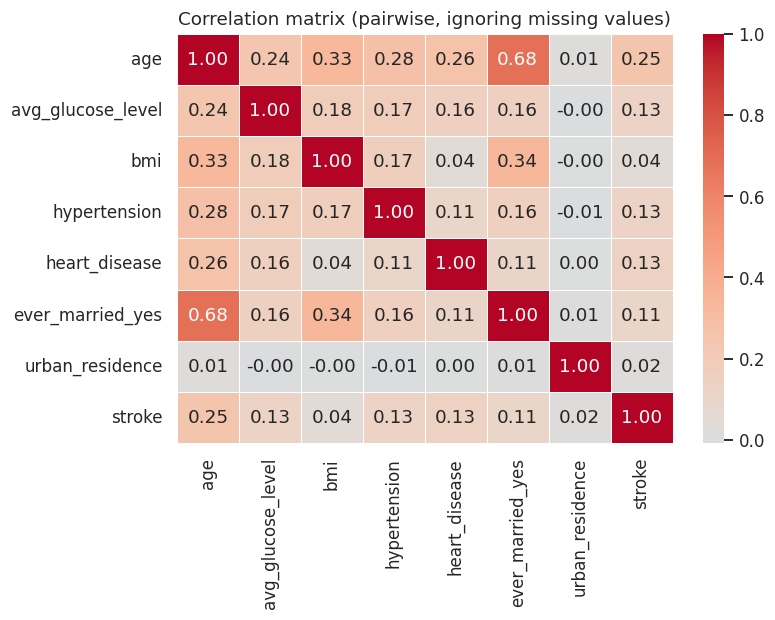

In [11]:
eda = df.copy()
eda["ever_married_yes"] = (eda["ever_married"] == "Yes").astype(int)
eda["urban_residence"] = (eda["Residence_type"] == "Urban").astype(int)
corr_cols = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease",
             "ever_married_yes", "urban_residence", "stroke"]
fig, ax = plt.subplots(figsize=(7.5, 5.8))
sns.heatmap(eda[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax)
ax.set_title("Correlation matrix (pairwise, ignoring missing values)")
plt.tight_layout(); plt.show()

**Observation:** `age` has the strongest correlation with `stroke` (about 0.25), followed by hypertension, heart disease and glucose level (about 0.13 each); BMI (0.04) and urban residence (about 0.01) are very weak. The only strong link between features is `age` with `ever_married_yes` (about 0.68), confirming the age effect noted above, so models in later parts should be interpreted with that overlap in mind.

### 5.7 Outlier check

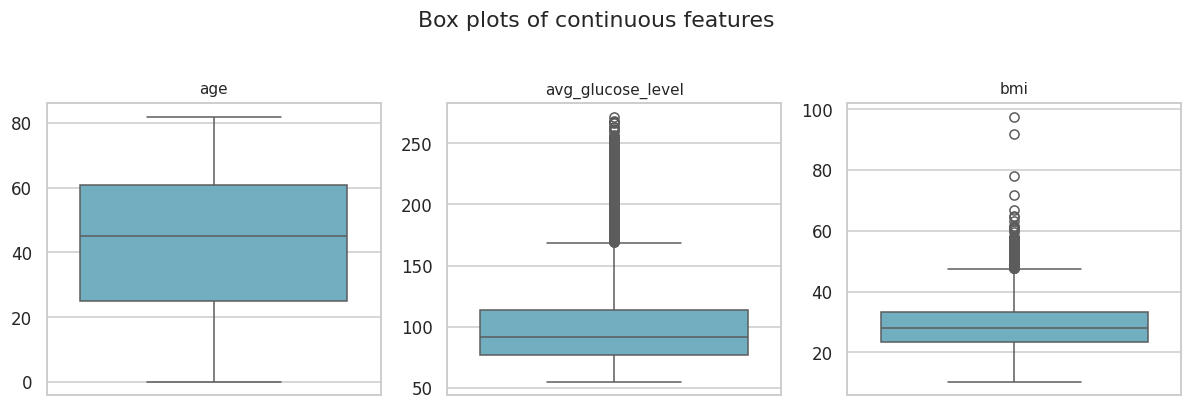

,feature,max_value,upper_fence_1.5,n_outliers_1.5,upper_fence_3.0,n_outliers_3.0
0,age,82.00,115.0,0,169.0,0
1,avg_glucose_level,271.74,169.4,627,224.6,166
2,bmi,97.60,47.5,110,61.9,8


In [12]:
cont_cols = ["age", "avg_glucose_level", "bmi"]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, c in zip(axes, cont_cols):
    sns.boxplot(y=df[c], ax=ax, color="#64b5cd")
    ax.set_title(c, fontsize=10); ax.set_ylabel("")
plt.suptitle("Box plots of continuous features", y=1.03)
plt.tight_layout(); plt.show()

# IQR rule outlier counts with the usual (1.5) and the more tolerant (3.0) fences (descriptive only)
rows = []
for c in cont_cols:
    s = df[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    row = [c, s.max()]
    for f in (1.5, 3.0):
        lo, hi = q1 - f * iqr, q3 + f * iqr
        row += [round(hi, 1), int(((s < lo) | (s > hi)).sum())]
    rows.append(row)
pd.DataFrame(rows, columns=["feature", "max_value", "upper_fence_1.5", "n_outliers_1.5",
                            "upper_fence_3.0", "n_outliers_3.0"])

**Observation:** `age` has no outliers. `avg_glucose_level` has 627 values above the usual 1.5×IQR fence (about 169 mg/dL) and `bmi` has 110 above its fence (about 47.5). Those high glucose values are **clinically meaningful** (diabetic range) and carry stroke information, so a tight cap would throw away signal. A looser **3×IQR** fence keeps genuine high glucose (only 166 values above about 225 mg/dL are capped) and only tames the extreme BMI values (8 patients above about 62, with a maximum of 97.6 that is physiologically implausible). We therefore **winsorise at 3×IQR**, with fences learned from the training data only, inside the pipeline.

## 6. Train / Test Split (done first, before any fitting)

The split is **stratified** on the target so both sets keep the same ~4.9% stroke rate. Every transformation below is fitted on `X_train` only.

In [13]:
X = df.drop(columns="stroke")
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Stroke patients -> train:", int(y_train.sum()), "| test:", int(y_test.sum()))
print("Stroke rate     -> train: {:.3f} | test: {:.3f}".format(y_train.mean(), y_test.mean()))

Train: (4088, 11) | Test: (1022, 11)
Stroke patients -> train: 199 | test: 50
Stroke rate     -> train: 0.049 | test: 0.049


## 7. Leakage-Free Preprocessing Pipeline

All preprocessing is wrapped in scikit-learn `Pipeline` / `ColumnTransformer` objects, so statistics (medians, means, outlier fences, category lists, feature scores) are learned from the training data only and merely *applied* to validation/test data.

| Step | Technique | Applied to | Fitted on |
| --- | --- | --- | --- |
| Drop identifier | `id` is left out of the `ColumnTransformer` | `id` | n/a |
| Feature construction | `ever_married_yes`, `urban_residence`, `bmi_missing`, `is_senior` (age ≥ 65), `comorbidity_count` (stateless formulas with fixed medical thresholds) | derived columns | nothing to fit |
| Missing values | Median imputer (numeric), most-frequent imputer (binary/categorical) | all columns | train only |
| Outliers | IQR winsorising with factor 3.0 (`OutlierCapper`, custom transformer) | numeric columns | train only |
| Scaling | `StandardScaler` | numeric columns | train only |
| Categorical encoding | `OneHotEncoder(handle_unknown="ignore")` | `gender`, `work_type`, `smoking_status` | train only |
| Feature selection | `SelectKBest(f_classif, k=18)` (ANOVA F-test) | all encoded features | train only |

### 7.1 Custom transformers

In [14]:
class OutlierCapper(BaseEstimator, TransformerMixin):
    """Winsorise numeric columns using IQR fences learned from the training data only."""
    def __init__(self, factor=3.0):
        self.factor = factor

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.feature_names_ = np.asarray(X.columns, dtype=object)
        q1, q3 = X.quantile(0.25), X.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = (q1 - self.factor * iqr).to_numpy()
        self.upper_ = (q3 + self.factor * iqr).to_numpy()
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return self.feature_names_
        return np.asarray(input_features, dtype=object)


def add_features(X):
    """Stateless feature construction (no statistics are learned, so no leakage)."""
    X = X.copy()
    X["ever_married_yes"] = (X["ever_married"] == "Yes").astype(int)
    X["urban_residence"] = (X["Residence_type"] == "Urban").astype(int)
    X["bmi_missing"] = X["bmi"].isna().astype(int)                       # missingness indicator
    X["is_senior"] = (X["age"] >= 65).astype(int)                         # fixed medical threshold
    X["comorbidity_count"] = X["hypertension"] + X["heart_disease"]       # 0, 1 or 2 conditions
    return X

### 7.2 Assemble the pipeline

In [15]:
numeric_features = ["age", "avg_glucose_level", "bmi", "comorbidity_count"]
binary_features  = ["hypertension", "heart_disease", "ever_married_yes",
                    "urban_residence", "bmi_missing", "is_senior"]
nominal_features = ["gender", "work_type", "smoking_status"]

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("cap_outliers", OutlierCapper(factor=3.0)),
    ("scale", StandardScaler()),
])
binary_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
])
nominal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Columns not listed here (id, and the raw ever_married / Residence_type text columns) are dropped
column_transformer = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("bin", binary_pipe, binary_features),
    ("nom", nominal_pipe, nominal_features),
], remainder="drop")
column_transformer.set_output(transform="pandas")

preprocessor = Pipeline([
    ("construct_features", FunctionTransformer(add_features)),
    ("transform_columns", column_transformer),
    ("select_features", SelectKBest(score_func=f_classif, k=18)),
])
preprocessor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('construct_features', ...), ('transform_columns', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...x7f94c8fbdbc0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional key

### 7.3 Fit on the training set only, then apply to both sets

In [16]:
X_train_prep = preprocessor.fit_transform(X_train, y_train)   # learns from TRAIN only
X_test_prep  = preprocessor.transform(X_test)                 # only applies what was learned

all_names = preprocessor.named_steps["transform_columns"].get_feature_names_out()
mask = preprocessor.named_steps["select_features"].get_support()
selected = list(all_names[mask])

print("Missing cells BEFORE preprocessing (train):", int(X_train.isna().sum().sum()))
print("Missing cells AFTER  preprocessing (train):", int(np.isnan(X_train_prep).sum()),
      "| (test):", int(np.isnan(X_test_prep).sum()))
print("\nFeatures after encoding :", len(all_names))
print("Features after selection:", len(selected))
print("Processed train shape   :", X_train_prep.shape)
print("Processed test shape    :", X_test_prep.shape)

Missing cells BEFORE preprocessing (train): 170
Missing cells AFTER  preprocessing (train): 0 | (test): 0

Features after encoding : 22
Features after selection: 18
Processed train shape   : (4088, 18)
Processed test shape    : (1022, 18)


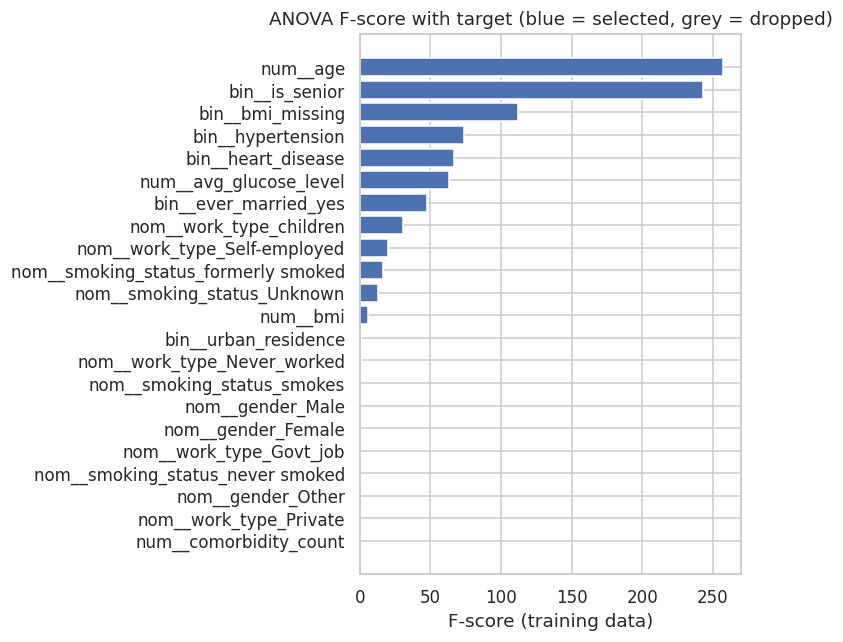

Top 6 features: ['num__age', 'bin__is_senior', 'bin__bmi_missing', 'bin__hypertension', 'bin__heart_disease', 'num__avg_glucose_level']
Dropped features: ['num__comorbidity_count', 'nom__gender_Other', 'nom__work_type_Private', 'nom__smoking_status_never smoked']


In [17]:
scores = preprocessor.named_steps["select_features"].scores_
fs = pd.Series(np.nan_to_num(scores), index=all_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#4c72b0" if n in selected else "#c0c0c0" for n in fs.index]
ax.barh(fs.index[::-1], fs.values[::-1], color=colors[::-1])
ax.set_title("ANOVA F-score with target (blue = selected, grey = dropped)")
ax.set_xlabel("F-score (training data)")
plt.tight_layout(); plt.show()
print("Top 6 features:", list(fs.index[:6]))
print("Dropped features:", [n for n in all_names if n not in selected])

**Observation:** `age`, the constructed `is_senior` and `bmi_missing` indicators, hypertension, heart disease and glucose level score highest, so two of the top three features are ones we constructed, which supports the feature-construction step. The four dropped features carry little information (`comorbidity_count`, which largely repeats hypertension and heart disease, plus the single `Other` gender row, `Private` work type and `never smoked`).

### 7.4 Proof that the pipeline is leakage-free

Three explicit checks:

1. The fitted scaler's mean must equal the **training** mean, not the full-dataset mean.
2. The outlier fences and imputation values must come from the **training** set.
3. The test set must not contain any patient who is also in the training set.

In [18]:
num_t = preprocessor.named_steps["transform_columns"].named_transformers_["num"]
imputer, capper, scaler = num_t.named_steps["impute"], num_t.named_steps["cap_outliers"], num_t.named_steps["scale"]

# Recreate constructed features, then apply the learned imputation values and fences
def prepared(frame):
    f = add_features(frame)[numeric_features]
    f = f.fillna(pd.Series(imputer.statistics_, index=numeric_features))
    return np.clip(f.to_numpy(dtype=float), capper.lower_, capper.upper_)

train_capped, full_capped = prepared(X_train), prepared(X)

print("Scaler mean == TRAIN mean :", np.allclose(scaler.mean_, train_capped.mean(axis=0)))
print("Scaler mean == FULL  mean :", np.allclose(scaler.mean_, full_capped.mean(axis=0)),
      " (expected False: test data did not influence the fit)")

idx = numeric_features.index("bmi")
print("Median BMI used for imputation (train):", imputer.statistics_[idx],
      "| train median:", X_train["bmi"].median())

s = X_train["avg_glucose_level"]
q1, q3 = s.quantile([0.25, 0.75])
print("Glucose upper fence (train):", round(q3 + 3 * (q3 - q1), 1),
      "| learned by pipeline:", round(capper.upper_[numeric_features.index("avg_glucose_level")], 1))

overlap = set(X_train["id"]) & set(X_test["id"])
print("Patients shared by train and test:", len(overlap))

assert np.allclose(scaler.mean_, train_capped.mean(axis=0))
assert imputer.statistics_[idx] == X_train["bmi"].median()
assert len(overlap) == 0
print("\nAll leakage checks passed.")

Scaler mean == TRAIN mean : True
Scaler mean == FULL  mean : False  (expected False: test data did not influence the fit)
Median BMI used for imputation (train): 28.0 | train median: 28.0
Glucose upper fence (train): 224.9 | learned by pipeline: 224.9
Patients shared by train and test: 0

All leakage checks passed.


## 8. Class Imbalance Handling

Only about 4.9% of patients had a stroke (about 199 positives in the 4,088 training rows). We handle this **without touching the test data**:

1. **Stratified splitting and stratified cross-validation** keep the stroke ratio identical in every fold, which matters when positives are this rare.
2. **Class weights** (`class_weight="balanced"`) make errors on the stroke class cost about 19 times more during training. Unlike oversampling, this does not create synthetic patients, so there is no risk of synthetic copies of a record leaking across folds.
3. **Imbalance-aware metrics**: ROC-AUC, PR-AUC (average precision), F1 and recall of the stroke class.

Oversampling such as SMOTE can be compared in Part 3 *inside* an `imblearn` pipeline if time allows.

## 9. Sanity Check: Does the Pipeline Work End-to-End?

To show that the full pipeline runs inside cross-validation (preprocessing is **re-fitted inside every fold**, so validation folds never influence it), we attach a simple Logistic Regression and run 5-fold stratified CV on the **training set only**. This is a pipeline check, not the project's modelling stage — the real model comparison starts in Part 2, and the **test set is left untouched**.

In [19]:
full_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
res = cross_validate(full_pipeline, X_train, y_train, cv=cv,
                     scoring=["roc_auc", "average_precision", "f1", "recall", "precision"])

summary = pd.DataFrame({
    "metric": ["ROC-AUC", "PR-AUC (avg. precision)", "F1 (stroke)", "Recall (stroke)", "Precision (stroke)"],
    "mean": [res["test_roc_auc"].mean(), res["test_average_precision"].mean(), res["test_f1"].mean(),
             res["test_recall"].mean(), res["test_precision"].mean()],
    "std": [res["test_roc_auc"].std(), res["test_average_precision"].std(), res["test_f1"].std(),
            res["test_recall"].std(), res["test_precision"].std()],
}).round(3)
print("Reference: PR-AUC of a random model equals the stroke rate =", round(y_train.mean(), 3))
summary

Reference: PR-AUC of a random model equals the stroke rate = 0.049


,metric,mean,std
0,ROC-AUC,0.853,0.011
1,PR-AUC (avg. precision),0.231,0.041
2,F1 (stroke),0.231,0.013
3,Recall (stroke),0.809,0.034
4,Precision (stroke),0.135,0.008


The pipeline runs without errors. Cross-validated **ROC-AUC is about 0.85** with very little variation between folds (standard deviation about 0.01). **Recall of the stroke class is about 0.81**, so the model finds most stroke patients, but **precision is only about 0.14** because with 5% positives and class weighting, many healthy patients are also flagged. PR-AUC (about 0.23) is far above the 0.049 of a random model but still modest, which is typical for a rare outcome. No step ever sees validation or test data during fitting. This logistic-regression result is only a **reference point**; Parts 2 and 3 will try to improve on it with Naive Bayes, decision trees and ensembles.

## 10. Summary of Part 1

| Requirement | What we did |
| --- | --- |
| Problem framing | Binary classification of `stroke`; metrics ROC-AUC, PR-AUC, recall and F1 of the stroke class (Section 1) |
| Missing values | `bmi` missing for 3.9% (informative), "Unknown" smoking category kept; median / most-frequent imputation plus `bmi_missing` indicator, fitted on train only (Sections 4, 5.2, 7) |
| Outliers | IQR winsorising at 3×IQR to keep clinically meaningful high glucose, fences learned on train only (Sections 5.7, 7) |
| Class imbalance | Stratified split/CV, class weights, imbalance-aware metrics (Section 8) |
| Scaling & encoding | `StandardScaler` for numeric features, one-hot encoding for `gender`, `work_type`, `smoking_status` (Section 7) |
| Feature construction / selection | `bmi_missing`, `is_senior`, `comorbidity_count` and others; `SelectKBest` with the ANOVA F-test (Section 7) |
| Leakage-free pipeline | `Pipeline` + `ColumnTransformer`, split-before-fit, identifier dropped, explicit leakage checks (Sections 4, 6, 7.4) |
| EDA | Seven visualisation sections (target balance, missing values, age, glucose and BMI, medical history and lifestyle, correlation heatmap, outlier box plots) |

**Decisions worth remembering:** no rows were deleted; `id` is excluded; the dataset is credited to fedesoriano on Kaggle; the stratified 80/20 split uses `random_state=42`; the test set (1,022 patients) is untouched.

**Next (Part 2):** reuse `preprocessor` and the same split to train and compare Naive Bayes and a decision tree, including a hand-computed information-gain split.